# **Assignment #1: EDA & Dataset**

**DATE: March2026**



### **Overview**

In this first assignment, you will gain hands-on experience selecting and preparing a dataset, performing exploratory data analysis (EDA), adding it to HF's Datasets, and presenting your findings in a short video.

Through these steps, you’ll begin building essential data science skills in Python.

Think of your notebook as a cohesive story where EDA reveals the narrative of your data, which provides the resolution to the main question or goal.

### **Objectives**

1. Explore various data tools/hubs (e.g., Kaggle, UCI, or local data) to find a suitable dataset.
2. Prepare the selected dataset, focusing on cleaning, transformation, manipulation, and quality.
3. Build foundational EDA skills, including  missing data, outlier handling, and clear data visualization.
4. Upload your work and your dataset to HuggingFace.
5. Communicate findings concisely in both a structured notebook, README file,  and a short video presentation, demonstrating clarity in each step of the workflow.

### **Submission Guidelines**

1. Please note that this is an individual assignment.
2. Submit a text file with your info and the link to HF's dataset.
3. The dataset will include all of your work.
  - **Python Notebook**: a well-structured notebook (e.g.`.ipynb` file) with clear comments or markdown explanations of each step.
  - **Video Link**: the README file will include your short video presentation at the beginning of the file.
4. **Oral Report**: Students may be randomly chosen to present their work in a quick online session with the T.A., typically lasting ±10 minutes.





### **Evaluation Criteria**

1. **Organization & Clarity (20%)**: Overall structure of your HF Dataset, code, notebook, clear communication, and a concise summary.

2. **Data Handling (30%)**: Quality of data cleaning, appropriate handling of outliers, and more.

3. **Visualizations (30%)**: well-presented relevant visuals, variety of plot types.

4. **Presentation (20%)**: Clearly communicated approach and findings in your 2–3 minute overview.


### **Additional Tips**

- The first thing you should do is download a copy of this notebook to your drive.
- Keep your dataset size manageable. If the dataset is large, you can sample a subset.
- A few clear visuals are more effective than many complicated ones.
- Ask for help or feedback early if you get stuck.

<br><br><br>

---

Reminder: Always start with copy the NOTEBOOK to your drive.

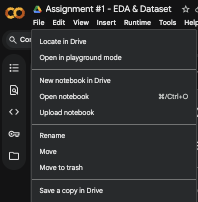

---

<br><br><br>

# **Part 1: Select a Dataset**

1. Choose a numeric tabular dataset, such as the . If you prefer, you may use other open-source datasets; [Hugginface](https://huggingface.co/datasets?task_categories=task_categories:tabular-classification&sort=trending), [Kaggle](https://www.kaggle.com/datasets?tags=13302-Classification&minUsabilityRating=8.00+or+higher), etc.


    Examples for a good dataset:
      - "Determine a genre of a song"
      - "Determine the type of flowers"
      - "Determine the animal - cat or dog"
      - "Determine the category of a product"
      - "Determine if an email is spam or not spam"
      - "Determine whether a tumor is malignant or benign"
      - "Determine whether a transaction is fraudulent or not"
      - "Determine whether a student is likely to pass a course"

2. Avoid choosing a "basic"/"small" dataset.
      - 1K rows and more.
      - 10 features and more.


3. Please submit your dataset [here](https://forms.gle/YYiRLXJnbwUfwuwc7), to share it with the class so everyone can see.
And make sure your chosen dataset is unique using this [link](https://docs.google.com/spreadsheets/d/1M8uojrzhSyVnOlSAJpzCKxrhWdzPR77k4x8Kxvr8VDk/edit?usp=sharing).

      *Note: Due to their popularity, the following are datasets you may not choose.*
      > - Iris dataset
      > - Wine dataset
      > - Titanic dataset
      > - Boston Housing dataset
      > - ImageNet, Cifar, CelebFaces, IMDB

> (If you happen to change the dataset - submit the new dataset. We're looking on the most current one)


4. Choose a dataset with moslty numaric values. This way you would have enough information to work on, and you could drop columns that aren't numeric.

5. Briefly describe your chosen dataset (source, size, features) and the question you want to answer.

6. Clearly identify the target variable to predict (if exists).






# Part 1

The chosen dataset "Flight Delay Dataset — 2024" from kaggle.
It contains 7M+ rows and 35 columms in 1.31GB.

Research question "Can we predict flight arrival delay (in minutes) based on scheduled timing, departure performance, and operational metrics?"


The target variable for this prediction task is arr_delay (Arrival Delay), which represents the difference in minutes between the scheduled and actual arrival time of a flight.

Positive values - the flight arrived late

Negative values - the flight arrived early

Zero - the flight arrived exactly on time

<br><br><br>

---

<br><br><br>

# **Part 2: Exploratory Data Analysis (EDA)**

Use your EDA to tell the story of your data - highlight interesting patterns, anomalies, or relationships that lead you toward your classification goal. Ask interesting questions, and answer them.


1. **Data Cleaning** : Check for missing values, duplicate entries, scaling/normalize issues,  parsing dates, fixing typos, or any inconsistencies.  Document how you address them.
2. **Outlier Detection & Handling**: Identify outliers and decide whether to keep or remove them, providing a short justification.
3. **Descriptive Statistics**: Summarize the data (e.g., mean, median, correlations) to reveal patterns.
4. Read further on [A Comprehensive Guide to Mastering Exploratory Data Analysis](https://www.dasca.org/world-of-data-science/article/a-comprehensive-guide-to-mastering-exploratory-data-analysis).
5. **Visualizations**: Use a set of  plots (e.g., histograms, scatter plots, box plots) to illustrate **key insights.** Label charts, axes, and legends clearly.

Tip: not necessarily in this order.

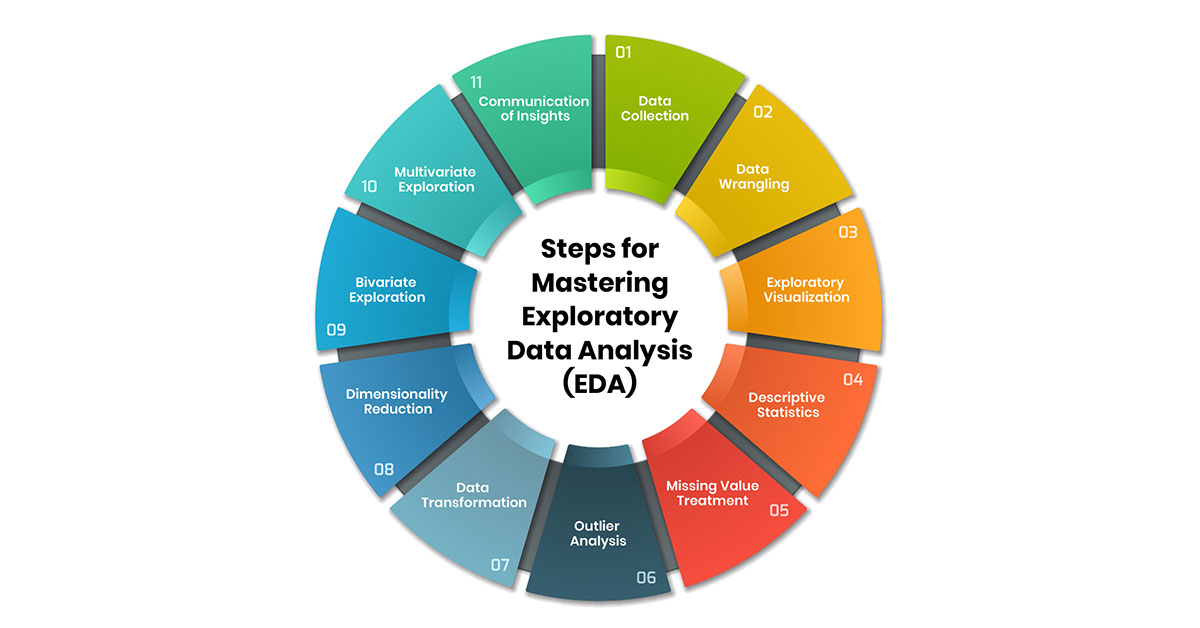

In [2]:
!pip install -q kagglehub
import kagglehub              # Installing kagglehub to allow direct download from Kaggle to Colab
import os

In [3]:
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")
print("Path to dataset files:", path)
print("Files in folder:", os.listdir(path))

# Downloading the Dataset from Kaggle using its Dataset ID and printing the path to confirm
# the download was successful

Using Colab cache for faster access to the 'flight-data-2024' dataset.
Path to dataset files: /kaggle/input/flight-data-2024
Files in folder: ['flight_data_2024_sample.csv', 'flight_data_2024_data_dictionary.csv', 'flight_data_2024.csv']


In [4]:
import pandas as pd

file_path = os.path.join(path, "flight_data_2024.csv")
df = pd.read_csv(file_path, nrows=100000)               # Sampling tha data due to its large size (7M+ rows)

df.head()                                              # Previewing the first 5 rows to get a quick look at the structure and column names

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.info()

# Checking the number of rows and columns, listing all features names and reviewing data types
# and non-null counts to spot issues ahead

Shape: (100000, 35)

Columns:
['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 100000 non-null  int64  
 1   month                100000 non-null  int64  
 2   day_of_month         100000 non-null  int64  
 3   day_of_week          100000 non-null  int64  
 4   fl_date              1

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

# Counting missing values per column to decide which columns
# need to be cleaned or dropped before analysis

,0
cancellation_code,99649
actual_elapsed_time,470
arr_delay,470
air_time,470
wheels_on,366
taxi_in,366
arr_time,366
wheels_off,345
taxi_out,345
dep_delay,335


In [7]:
df = df[df['cancelled'] == 0]  # remove cancelled flights

df = df.dropna(subset=['arr_delay'])  # remove rows without target variable

print("New shape:", df.shape)

New shape: (99530, 35)


In [8]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Checking for exact duplicate rows to ensure each flight record is unique
# and won't be counted more than once

Duplicate rows: 0


In [9]:
df[['arr_delay', 'dep_delay', 'distance', 'air_time']].describe()

# Taking the features that affect the targert value and make sure they are all numeric values

,arr_delay,dep_delay,distance,air_time
count,99530.000000,99530.000000,99530.000000,99530.000000
mean,0.456636,7.821591,868.022857,119.412911
std,45.701285,43.530112,604.293149,71.582382
min,-80.000000,-38.000000,31.000000,8.000000
25%,-17.000000,-6.000000,416.000000,66.000000
50%,-8.000000,-2.000000,738.000000,104.000000
75%,5.000000,6.000000,1103.000000,150.000000
max,1676.000000,1675.000000,5095.000000,647.000000


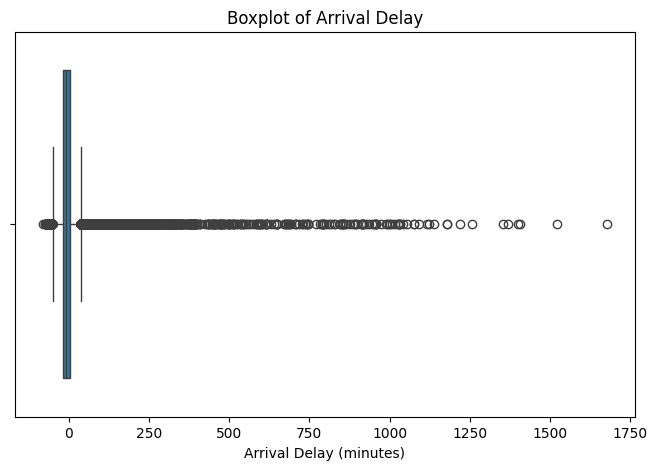

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Visualizing the distribution of arrival delays to detect outliers
sns.boxplot(x=df['arr_delay'])
plt.title("Boxplot of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

In [11]:
# Removing extreme outliers — delays below -100 or above +300 minutes
# represent rare anomalies (diversions, cancellations miscoded) that would distort
# the data. this affects less than 0.3% of the data

df_clean = df[(df['arr_delay'] >= -100) & (df['arr_delay'] <= 300)]

print("Original shape:", df.shape)
print("After removing extreme outliers:", df_clean.shape)

Original shape: (99530, 35)
After removing extreme outliers: (99246, 35)


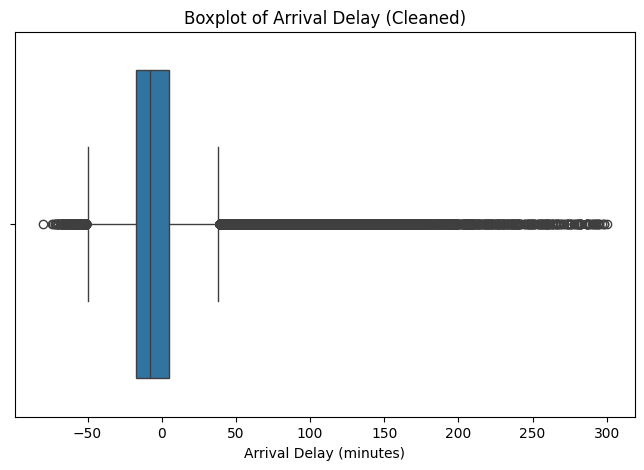

In [12]:
plt.figure(figsize=(8,5))

# Re-plotting the arrival delay distribution after outlier removal
# to confirm the data is now within a reasonable and realistic range
sns.boxplot(x=df_clean['arr_delay'])
plt.title("Boxplot of Arrival Delay (Cleaned)")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

### **Research:** Pose relevant questions about your dataset, then answer them using visual elements (e.g. charts or plots) to provide clear insights.

For example, in the 2nd lecture the entire class took a survey. Then, we talked about the collected data and desplayed the collected data using the right **plots** - Lines, Bars, Hist, Pie, Map, HeatMap, Area, Time, etc.

An aditional more specific example, would be the questions we asked during the recitation on the `Titanic` dataset:
  - "Did survival rates differ by gender?"
  - "Was passenger class related to survival?"
  - "What was the age distribution of survivors vs. non-survivors?"
  - "Did embarking location (port) have any effect on survival?"    
  
And how we answered those questions using **plots**.

The idea is to pose questions that can uncover patterns, correlations, or anomalies in your dataset, then back those up with clean, insightful visualizations.

# Research Questions

**Question 1: Which airlines have the highest average arrival delay?**

Airlines operate very differently in terms of scheduling and efficiency. By comparing the average arrival delay per carrier, we can identify which airlines are the most and least delays.

/tmp/ipykernel_17490/3654168968.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_delay_by_carrier, x='Avg Arrival Delay (min)', y='Carrier', palette='coolwarm_r')


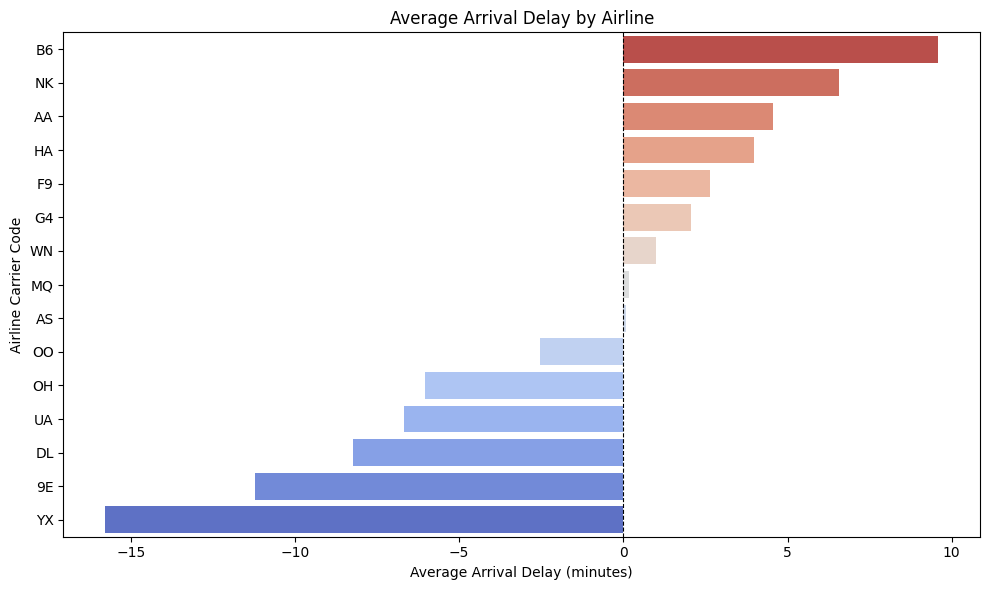

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by airline and calculate average arrival delay
grouped = df_clean.groupby('op_unique_carrier')['arr_delay'].mean()

# Sort from highest to lowest delay
sorted_grouped = grouped.sort_values(ascending=False)

# Convert to a clean DataFrame
avg_delay_by_carrier = sorted_grouped.reset_index()
avg_delay_by_carrier.columns = ['Carrier', 'Avg Arrival Delay (min)']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_delay_by_carrier, x='Avg Arrival Delay (min)', y='Carrier', palette='coolwarm_r')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airline Carrier Code')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # line at 0 = on time
plt.tight_layout()
plt.savefig('q1_airlines.png', bbox_inches='tight')
plt.show()

**Question 2: Does the time of day affect arrival delays?**

Flights later in the day may accumulate delays due to earlier flights running behind schedule. This question explores whether departure hour has a pattern of increasing or decreasing arrival delays throughout the day.

/tmp/ipykernel_17490/973955781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['dep_hour'] = (df_clean['crs_dep_time'] // 100).astype(int)
/tmp/ipykernel_17490/973955781.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_delay_by_hour, x='Departure Hour', y='Avg Arrival Delay (min)', palette='coolwarm')


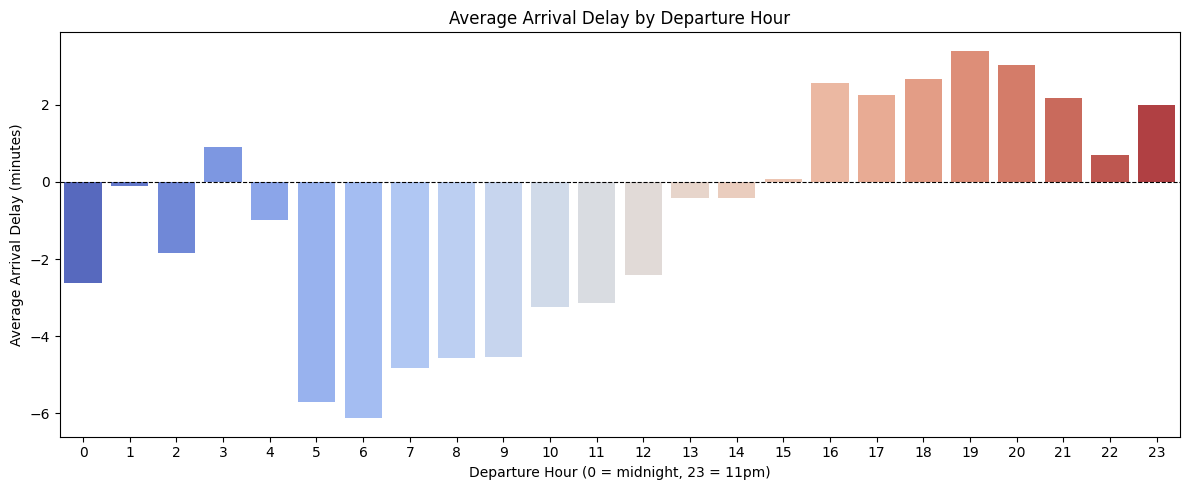

In [14]:
# Extract the departure hour from the scheduled departure time
df_clean['dep_hour'] = (df_clean['crs_dep_time'] // 100).astype(int)

# Calculate average arrival delay for each hour
avg_delay_by_hour = df_clean.groupby('dep_hour')['arr_delay'].mean()
avg_delay_by_hour = avg_delay_by_hour.reset_index()
avg_delay_by_hour.columns = ['Departure Hour', 'Avg Arrival Delay (min)']

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_delay_by_hour, x='Departure Hour', y='Avg Arrival Delay (min)', palette='coolwarm')
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour (0 = midnight, 23 = 11pm)')
plt.ylabel('Average Arrival Delay (minutes)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # line at 0 = on time
plt.tight_layout()
plt.savefig('q2_time_of_day.png', bbox_inches='tight')
plt.show()

**Question 3: Which departure airports have the highest average arrival delay?**

Some airports are more delay-prone than others due to traffic volume, weather conditions, or infrastructure. This question identifies the top 15 busiest origin airports and compares their average arrival delays.

/tmp/ipykernel_17490/2534127443.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_delay_by_airport, x='Avg Arrival Delay (min)', y='Airport', palette='coolwarm_r')


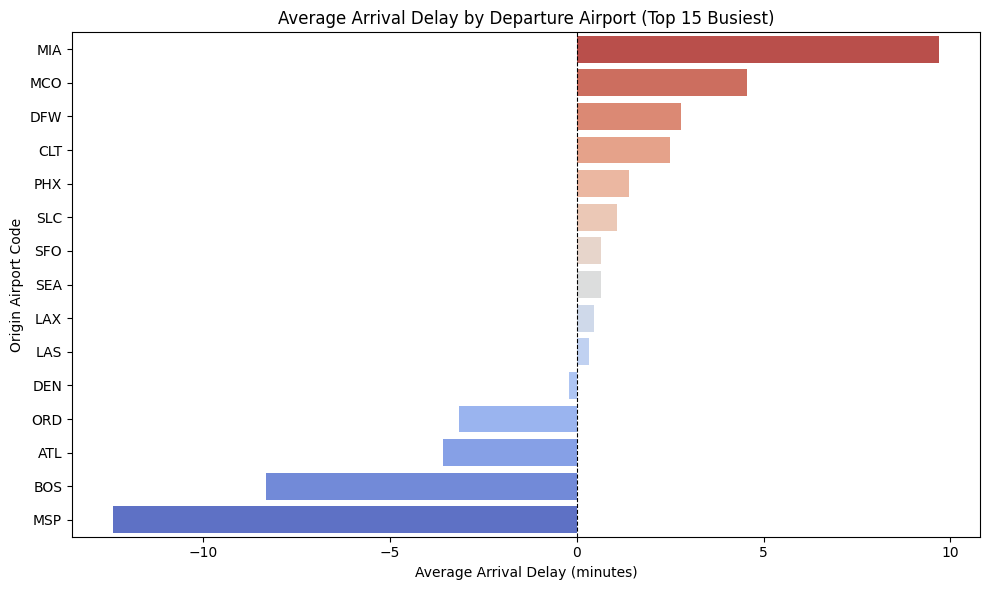

In [15]:
# Find the top 15 most frequent departure airports
top_airports = df_clean['origin'].value_counts().head(15).index

# Filter data to only include those airports
df_top_airports = df_clean[df_clean['origin'].isin(top_airports)]

# Calculate average arrival delay per airport
avg_delay_by_airport = df_top_airports.groupby('origin')['arr_delay'].mean()
avg_delay_by_airport = avg_delay_by_airport.sort_values(ascending=False)
avg_delay_by_airport = avg_delay_by_airport.reset_index()
avg_delay_by_airport.columns = ['Airport', 'Avg Arrival Delay (min)']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_delay_by_airport, x='Avg Arrival Delay (min)', y='Airport', palette='coolwarm_r')
plt.title('Average Arrival Delay by Departure Airport (Top 15 Busiest)')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Origin Airport Code')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

In [16]:
import plotly.express as px

In [17]:
# Airport coordinates for top 30 US airports
airport_coords = {
    'ATL': (33.64, -84.43), 'LAX': (33.94, -118.41), 'ORD': (41.98, -87.90),
    'DFW': (32.90, -97.04), 'DEN': (39.86, -104.67), 'JFK': (40.64, -73.78),
    'SFO': (37.62, -122.38), 'SEA': (47.45, -122.31), 'LAS': (36.08, -115.15),
    'MCO': (28.43, -81.31), 'CLT': (35.21, -80.94), 'PHX': (33.44, -112.01),
    'MIA': (25.80, -80.29), 'BOS': (42.36, -71.01), 'MSP': (44.88, -93.22),
    'EWR': (40.69, -74.17), 'DTW': (42.21, -83.35), 'PHL': (39.87, -75.24),
    'LGA': (40.77, -73.87), 'BWI': (39.18, -76.67), 'IAH': (29.99, -95.34),
    'MDW': (41.79, -87.75), 'TPA': (27.98, -82.53), 'PDX': (45.59, -122.60),
    'SAN': (32.73, -117.19), 'HOU': (29.65, -95.28), 'DAL': (32.85, -96.85),
    'AUS': (30.19, -97.67), 'RDU': (35.88, -78.79), 'SLC': (40.79, -111.98)
}

# Get airports that exist in our dataset
top_airports = list(airport_coords.keys())
df_top = df_clean[df_clean['origin'].isin(top_airports)]

# Calculate average arrival delay per airport
avg_delay = df_top.groupby('origin')['arr_delay'].mean()
avg_delay = avg_delay.reset_index()
avg_delay.columns = ['Airport', 'Avg Delay (min)']

# Add coordinates
avg_delay['lat'] = avg_delay['Airport'].map(lambda x: airport_coords[x][0])
avg_delay['lon'] = avg_delay['Airport'].map(lambda x: airport_coords[x][1])

# Round for cleaner hover labels
avg_delay['Avg Delay (min)'] = avg_delay['Avg Delay (min)'].round(2)

# Plot interactive map
fig = px.scatter_geo(avg_delay,
                     lat='lat',
                     lon='lon',
                     color='Avg Delay (min)',
                     size=avg_delay['Avg Delay (min)'].abs() + 8,  # +8 so even near-zero airports show up
                     hover_name='Airport',
                     hover_data={'Avg Delay (min)': True, 'lat': False, 'lon': False},
                     color_continuous_scale='RdBu_r',
                     scope='usa',
                     text='Airport',  # show airport code as label
                     title='Average Arrival Delay by Departure Airport (Top 30 US Airports)')

# Make labels visible and dots more prominent
fig.update_traces(
    textposition='top center',
    textfont=dict(size=10, color='black'),
    marker=dict(opacity=0.85, line=dict(width=1, color='white'))
)

fig.update_layout(
    geo=dict(bgcolor='lightblue'),  # light blue background for the map
    title_font_size=16
)

fig.show()

# Save as interactive HTML
fig.write_html('q3_map.html')
print("Interactive map saved as q3_map.html")

Interactive map saved as q3_map.html


**Question 4: How do numerical features correlate with arrival delay?**

A correlation heatmap shows how strongly each variable in the dataset relates to the others. Values close to 1 or -1 indicate a strong relationship, while values near 0 indicate little to no relationship. This helps us identify which features will be most useful for predicting arr_delay (arrival delay).

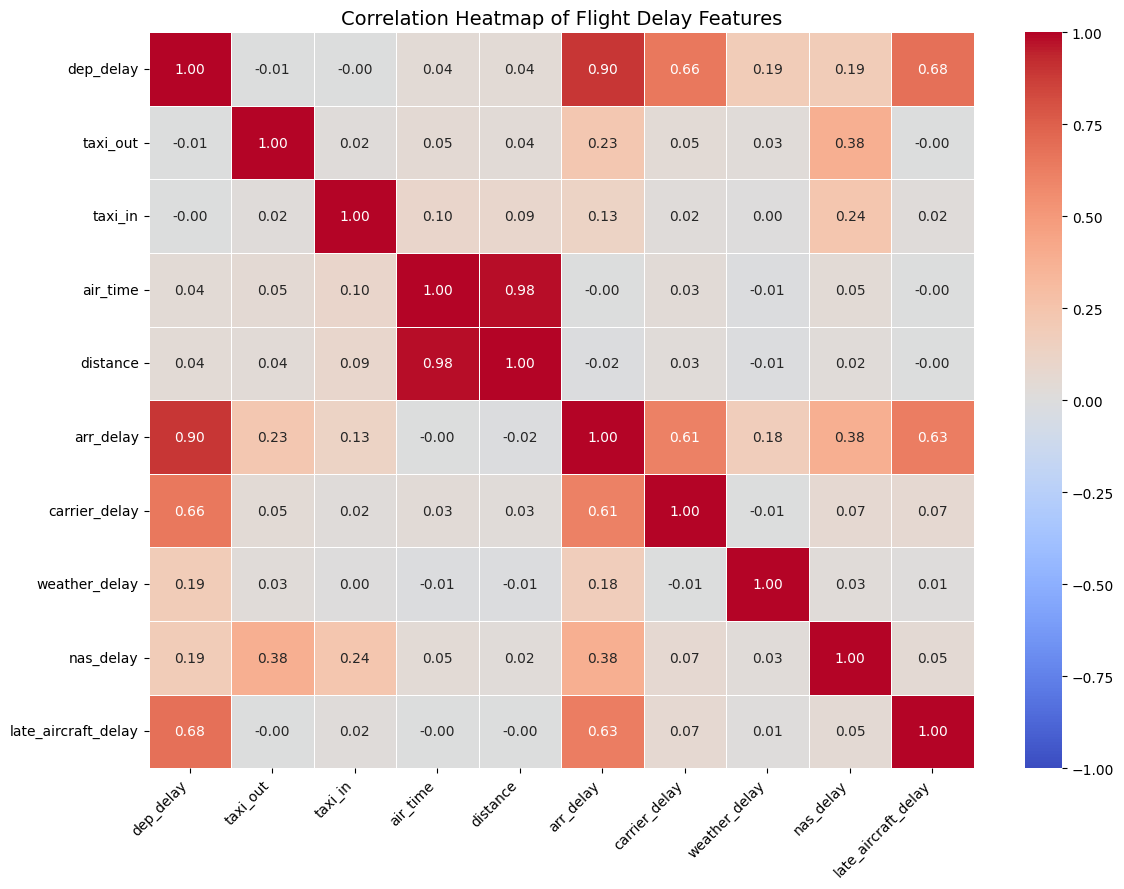

In [18]:
# Select only the relevant numeric columns
numeric_cols = ['dep_delay', 'taxi_out', 'taxi_in', 'air_time',
                'distance', 'arr_delay', 'carrier_delay',
                'weather_delay', 'nas_delay', 'late_aircraft_delay']

# Calculate correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Flight Delay Features', fontsize=14)
plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)               # keep y labels horizontal
plt.tight_layout()
plt.savefig('q4_heatmap.png', bbox_inches='tight')
plt.show()

<br><br><br>

---

<br><br><br>

# **Part 3: README file**

1. Upload the dataset to HuggingFace.

2. Upload your work (this notebook) as a `.ipynb` file your HF's Dataset.

3. Create a `README` file in a Markdown format. This page should include the end result of your work. Meaning include the visualizations, Questions, Answers, insights, Decisions, and more.


In [ ]:
readme_content = """#  U.S. Flight Delay Dataset — 2024

## Dataset Overview
- **Source:** Kaggle — [Flight Data 2024](https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024)
- **Size:** 100,000 rows sampled, 35 columns
- **Target Variable:** `arr_delay` — Arrival delay in minutes (positive = late, negative = early)
- **Goal:** Predict flight arrival delay in minutes based on scheduled timing, departure performance, and operational metrics.

---

##  Data Cleaning Decisions
- Removed cancelled flights (`cancelled == 0`) — they have no arrival time
- Removed rows with missing `arr_delay` values
- Removed extreme outliers: delays below -100 or above +300 minutes (less than 0.3% of data)
- No duplicate rows were found

---

##  Key Findings

- Flights that depart late usually arrive late (`0.90 correlation`)
- Delays build throughout the day and peak around evening hours
- Florida airports showed the highest average delays in the sample
- Distance and airtime had almost no relationship with delays
- Regional and premium carriers performed better on average

---

##  Target Variable: `arr_delay`
The target variable is **arr_delay** (Arrival Delay), which represents the difference in minutes between the scheduled and actual arrival time of a flight.
- Positive values → the flight arrived late
- Negative values → the flight arrived early
- Zero → the flight arrived exactly on time

Since arr_delay is a numeric value measured in minutes, predicting it is a regression task..

---

##  Research Questions & Insights

### Q1: Which airlines have the highest average arrival delay?
Airlines operate very differently in terms of scheduling and efficiency. By comparing average arrival delay per carrier, we can identify the most and least punctual airlines.

![Q1](q1_airlines.png)

**Insight:** B6 (JetBlue) and NK (Spirit) have the highest average delays (~9–6 minutes late).
YX (Republic Airways - American Eagle, Delta Connection, United Express) 9E (regional fully owned by Delta), and DL (Delta) consistently arrive ahead of schedule.
Budget and low-cost carriers tend to run later than regional ones.

---

### Q2: Does the time of day affect arrival delays?
Flights later in the day may accumulate delays due to earlier flights running behind — the "delay snowball" effect.

![Q2](q2_time_of_day.png)

**Insight:** Early morning flights (5–6am) arrive significantly ahead of schedule due to low airport congestion. Delays build up through the day, peaking around 7pm. This confirms that delays cascade as the day progresses.

---

### Q3: Which departure airports have the highest average arrival delay?

![Airport delay map](./q3_map.png)

**Insight:** Florida airports (MIA, MCO) are the most delay-prone, likely due to heavy tourist traffic and frequent thunderstorms. MSP, BOS, and ATL tend to perform better on average.

[🗺️ Open the interactive map](https://huggingface.co/spaces/avihayamor/flight-delay-map-2024)

---

### Q4: How do numerical features correlate with arrival delay?
A correlation heatmap shows how strongly each variable relates to the others, helping identify the best predictors of `arr_delay`.

![Q4](q4_heatmap.png)

**Insight:** `dep_delay` has a 0.90 correlation with `arr_delay` — by far the strongest predictor. If a flight departs late, it almost certainly arrives late. `carrier_delay` (0.61) and `late_aircraft_delay` (0.63) also contribute significantly. Interestingly, `distance` and `air_time` have almost zero correlation with delays — how far or long a flight is doesn't affect whether it's delayed.

---

## Presentation Video

<video width="900" controls>
  <source src="https://huggingface.co/datasets/avihayamor/US_flight-delay-2024/resolve/main/Data%20Science%20Vid.mp4" type="video/mp4">
</video>

*For quick reference, the key findings are summarized at the top of this page.*
---

##  Author

**Avihay Amor**
B.A. Economics & Entrepreneurship
Reichman University
2026

##  Files in this Dataset
- `flight_data_2024_sample.csv` — cleaned sample of 100,000 flights
- `Assignment_1_EDA_&_Dataset_Avihay_Amor.ipynb` — full EDA notebook
- `q1_airlines.png` — bar chart: average delay by airline
- `q2_time_of_day.png` — bar chart: average delay by hour
- `q3_map.html` — interactive map: delay by departure airport
- `q4_heatmap.png` — correlation heatmap
- `Data_Science_Vid.MP4` — presentation video

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
# Re-save map with CDN-only Plotly JS (much smaller file, works when opened directly)
fig.write_html('q3_map.html', include_plotlyjs='cdn')
print("Fixed q3_map.html saved (CDN version, much smaller)")

# Verify file size
import os
size_kb = os.path.getsize('q3_map.html') / 1024
print(f"New file size: {size_kb:.1f} KB")

# Also update README to use the direct HF resolve link for the map
hf_map_url = "https://huggingface.co/datasets/avihayamor/US_flight-delay-2024/resolve/main/q3_map.html"

with open('README.md', 'r') as f:
    readme = f.read()

# Replace the relative link with the absolute HF resolve link
readme_fixed = readme.replace(
    '[🗺️ View Interactive Map](q3_map.html)',
    f'[🗺️ View Interactive Map]({hf_map_url})'
)

with open('README.md', 'w') as f:
    f.write(readme_fixed)

print("README.md updated with direct HF map link")

Fixed q3_map.html saved (CDN version, much smaller)
New file size: 10.5 KB
README.md updated with direct HF map link


<br><br><br>

---

<br><br><br>

# **Part 4: Presentation Video**

- Record a brief video (2–3 minutes) with screen sharing of you walk through the HF's Dataset, README, notebook and sharing your process & results. Make sure to include a screen share while also recording yourself talking during the walk through.

- Videos without your face talking while going ower your work wont be acceptable.

- You should include:
  - A quick dataset overview and your main goal.
  - Key EDA steps and highlights of visual insights. (!)
  - Reflections on any challenges and lessons learned.


> For help:
> - Youtube [Watch this video](https://www.youtube.com/watch?v=DK7Z_nYhjjg)
> - Loom [Watch this video](https://www.youtube.com/watch?v=eSCHNXTsJK8)
> - Zoom [Watch this video](https://www.youtube.com/watch?v=njwbjFYCbGU)


Upload the video to the Dataset Repo, as a `MP4` file.

Then include the video on the dataset README file, as follows:

`<video src="..." controls="controls" style="max-width: 720px;"></video>`



Finally, attach the video to the begining of the `README` file, and make sure everything works.

In [ ]:
# here is a simple example on including the video in the README: https://huggingface.co/miqudev/miqu-1-70b

<br><br><br>

# **Part 5: Moodle**

**Submit to Moodle the link to your HF's Dataset.**  

> As the dataset already includes the video presentation, and the code notebook - we should haver everything there to examine.


In [ ]:
# Link example: https://huggingface.co/datasets/ido_something/name_of_ds

<iframe src="https://www.youtube.com/watch?v=eSCHNXTsJK8&list=PLi-p30WVfEiDw5I6xBGLPbowJJtjyu_b2&index=4&ab_channel=Loom" frameborder="0" allowfullscreen></iframe>



---

Good luck and have fun exploring your first DS project!